In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
df=pd.read_csv('hasil pengujian model.csv')
df

,Versi,Kelas,Nama,Keterangan
0,nano,A,Yusri Afta Putra,Berhasil
1,nano,B,Yusri Afta Putra,Berhasil
2,nano,C,Yusri Afta Putra,Berhasil
3,nano,D,Yusri Afta Putra,Berhasil
4,nano,E,Yusri Afta Putra,Berhasil
...,...,...,...,...
415,large,rumah,Muhammad Faqih Himawan,Berhasil
416,large,saya,Muhammad Faqih Himawan,Berhasil
417,large,terima,Muhammad Faqih Himawan,Berhasil
418,large,tidur,Muhammad Faqih Himawan,Berhasil


In [8]:
status_to_num = {
    "Gagal": 0,
    "Berhasil": 1
}

df["Status_Num"] = df["Keterangan"].map(status_to_num)


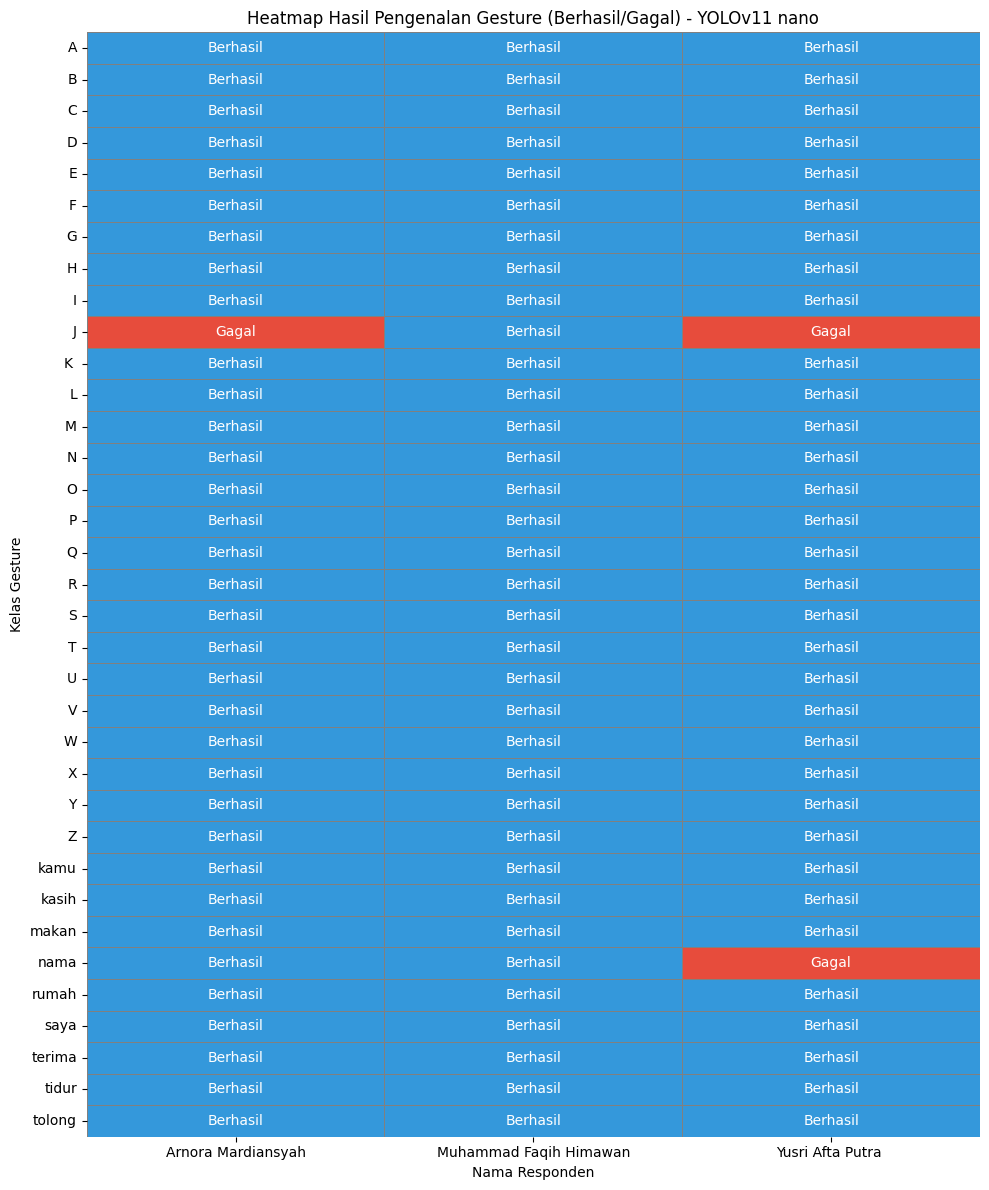

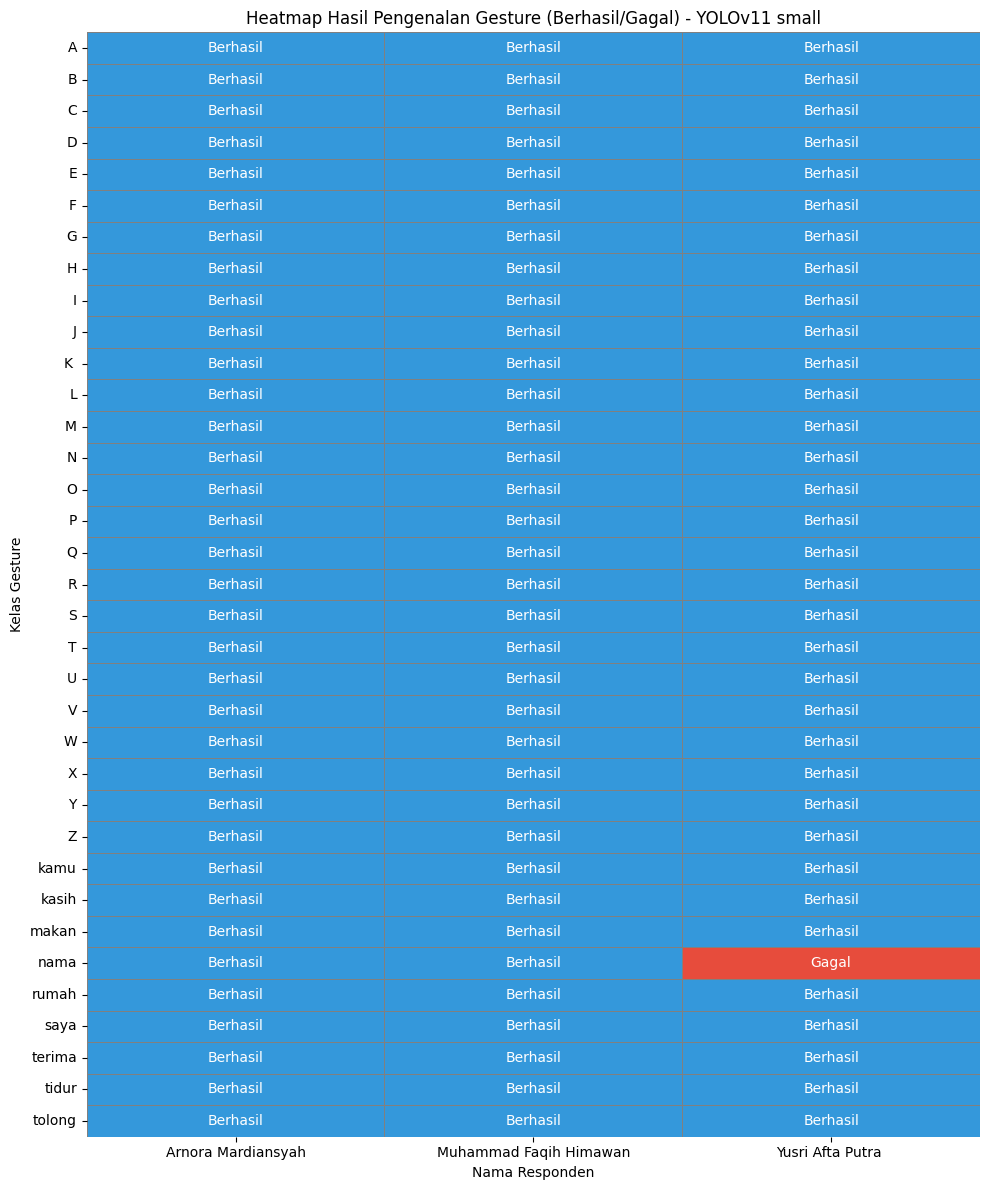

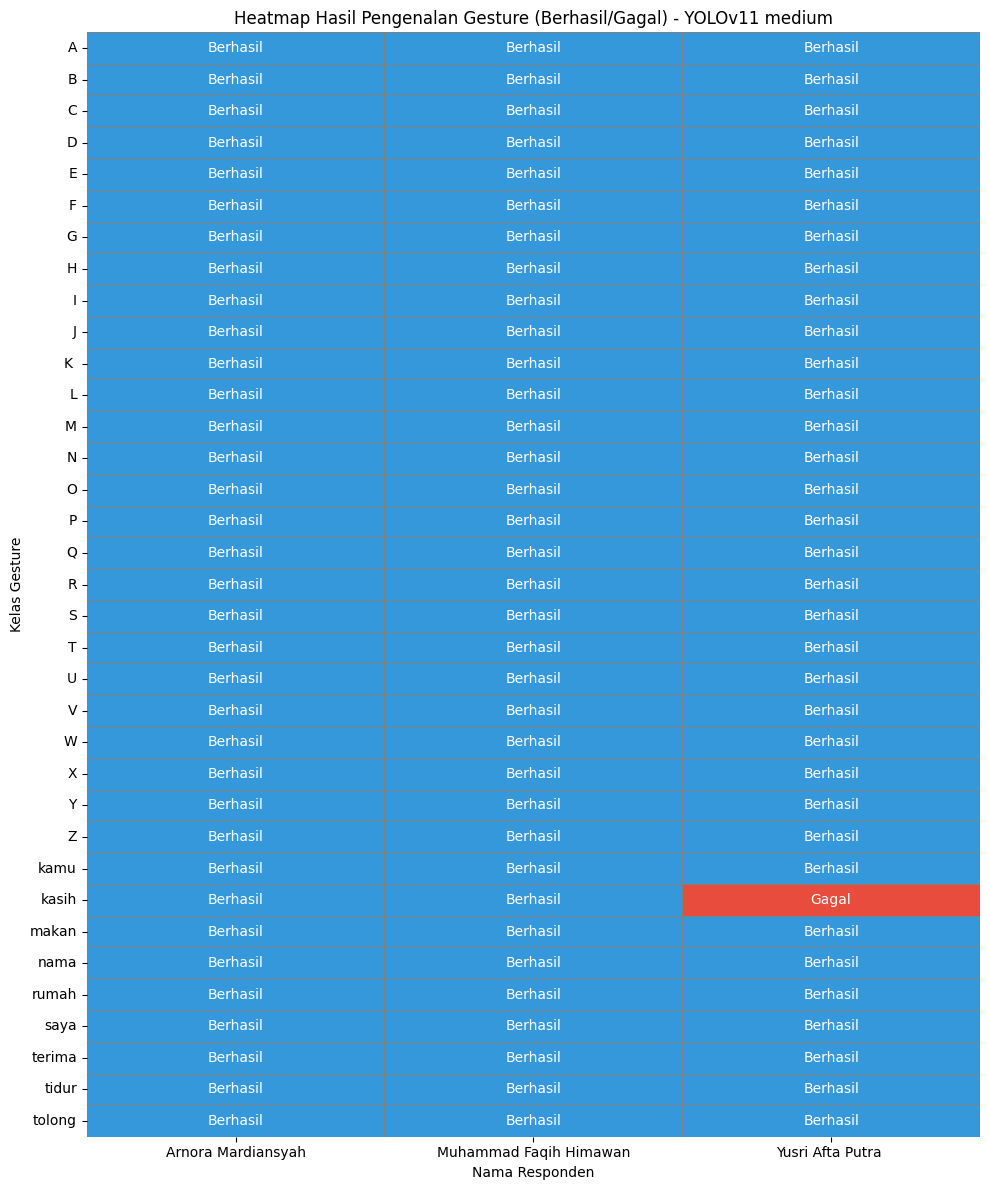

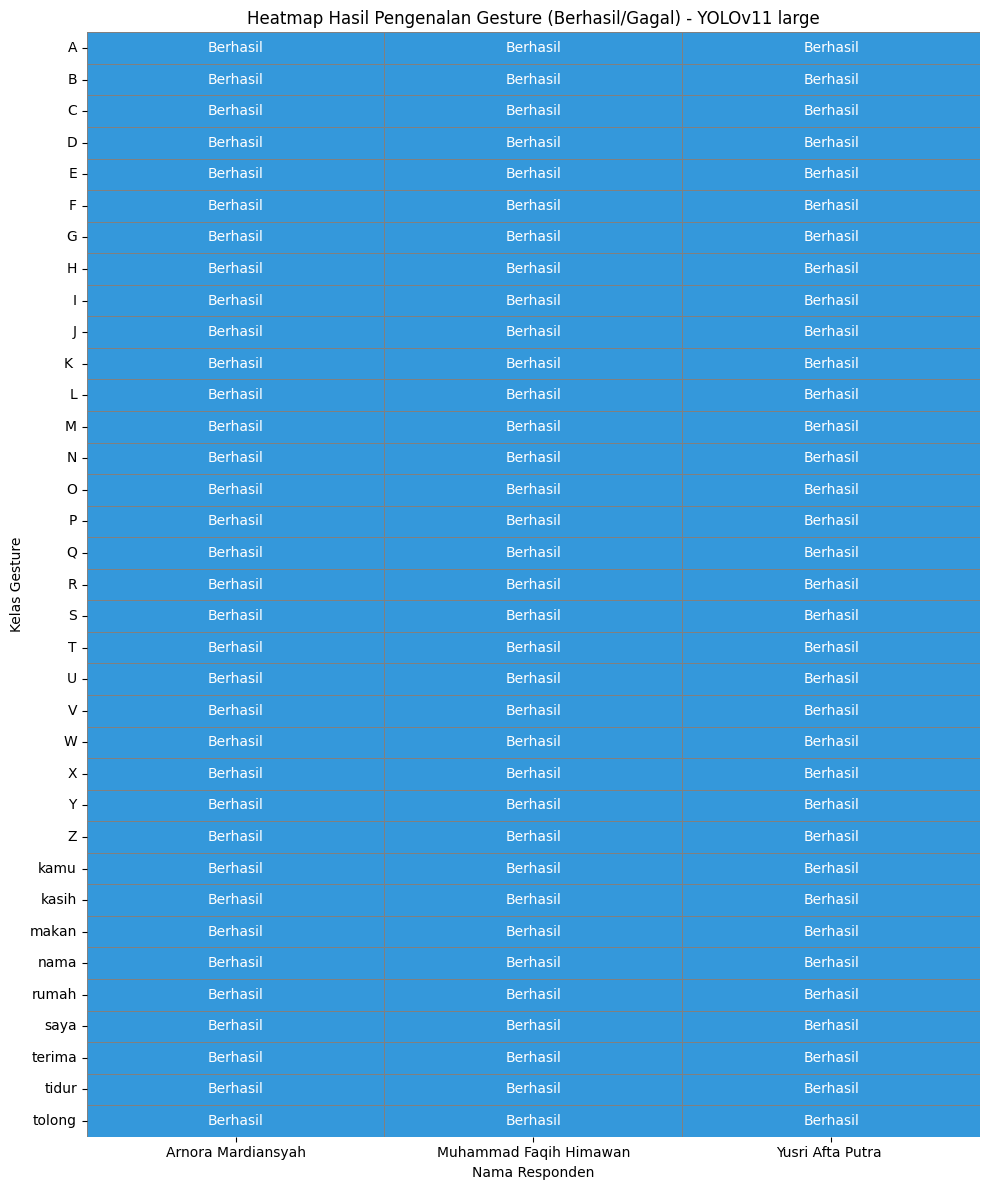

In [13]:
for versi in df["Versi"].unique():
    df_v = df[df["Versi"] == versi]

    # Pivot: Kelas sebagai baris, Nama sebagai kolom
    pivot_num = df_v.pivot(
        index="Kelas",
        columns="Nama",
        values="Status_Num"
    )

    pivot_label = df_v.pivot(
        index="Kelas",
        columns="Nama",
        values="Keterangan"
    )

    plt.figure(figsize=(10, 12))
    sns.heatmap(
        pivot_num,
        annot=pivot_label,
        fmt="",
        cmap=["#e74c3c", "#3498db"],  # merah=gagal, biru=berhasil
        cbar=False,
        linewidths=0.5,
        linecolor="gray",
        vmin=0,
        vmax=1
    )


    plt.title(f"Heatmap Hasil Pengenalan Gesture (Berhasil/Gagal) - YOLOv11 {versi}")
    plt.xlabel("Nama Responden")
    plt.ylabel("Kelas Gesture")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
